In [ ]:
from google.colab import files

import scipy.io

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import CCA

## Analisando resultado CCA

### Carregar arquivos

In [ ]:
# Carregue os dados do usuário aqui (no meu caso, utilizei os dados do usuário S3)
upload_files = files.upload()

### Obtendo sinal

In [ ]:
# para verificar utilizei os dados do usuário S3
data = scipy.io.loadmat('S3.mat')
eeg_signal = data['data']

### Preparando alguns parâmetros

In [ ]:
# frequências do experimento
# _freqs_trials = np.arange(8, 16, 0.2) # frequências erradas
_freqs_trials = [8.0, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0, 10.2, 10.4, 10.6, 10.8, 11.0, 11.2, 11.4, 11.6, 11.8, 12.0, 12.2,
                12.4, 12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0, 14.2, 14.4, 14.6, 14.8, 15.0, 15.2, 15.4, 15.6, 15.8]
# canais de interesse da EEG
_channels_sel = [47, 53, 54, 55, 56, 57, 58, 60, 61, 62]
# taxa de amostragem (250 Hz)
_samp_rate = 250
# Ponto inicial das janelas (recomendado iniciar em 0,64s = ponto 160)
_win_start = 160
# Tamanho da janela (utilizei 3 segundos)
_win_size = 3 * _samp_rate

---

### Funções

Função para janelamento

In [ ]:
def window(signal:np.ndarray, trial:int, channel:list=_channels_sel, size:tuple=(_win_start, _win_start + _win_size), block:int=None) -> np.ndarray:
  """
    Window function for EEG data
  """
  if block is not None:
    _signal = signal[channel, size[0]:size[1], trial, block]
  else:
    _signal = np.mean(signal[channel, size[0]:size[1], trial, :], axis=-1)
  return _signal

Função para gerar sinal de referência

In [ ]:
def reference_signals(freq:float, T:int, samprate:float, N:int=1, _verbose:bool=False) -> np.ndarray:
  """
    Reference signals function for N harmonics with T samples
  """
  if _verbose: print(f'Running reference signals for {freq=} | {T=} | {samprate=} | {N=}')

  n = np.arange(T) / samprate

  _ref = np.array([f((_n + 1) * 2 * np.pi * freq * n) for _n in range(N+1) for f in (np.sin, np.cos)])

  return _ref

Função para encontrar maior valor da CCA

In [ ]:
def cca_f(eeg:np.ndarray, ref:np.ndarray) -> float:
  """
    Canonical correlation analysis (CCA) function using sklearn
  """
  eeg = eeg.T
  ref = ref.T

  cca = CCA(n_components=1)
  cca.fit(eeg, ref)

  U, V = cca.transform(eeg, ref)

  corr = np.corrcoef(U.T, V.T)[0, 1]

  return corr

---

### Verificando respostas da CCA com gráfico

In [ ]:
# Frequência do trial (0 a 39)
_trial = 10
# Bloco
_block = 2
# Número de harmônicas (utilizei somente a primeira)
_n_har = 1

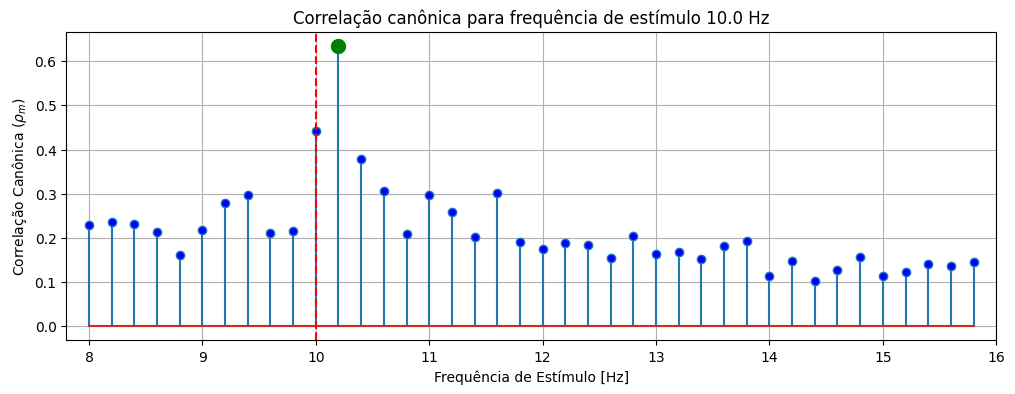

In [ ]:
rhos = np.zeros(len(_freqs_trials))
_eeg_signal = window(eeg_signal, _trial, block=_block)

for i, f in enumerate(_freqs_trials):
  _ref = reference_signals(f, _win_size, _samp_rate, _n_har)
  _cca = cca_f(_eeg_signal, _ref)
  rhos[i] = _cca

plt.figure(figsize=(12,4))
markerline, stemlines, baseline = plt.stem(_freqs_trials, rhos)
plt.setp(markerline, 'markerfacecolor', 'b')
plt.xlabel('Frequência de Estímulo [Hz]')
plt.ylabel('Correlação Canônica (${\\rho}_m$)')
plt.axvline(x=_freqs_trials[_trial], color='r', linestyle='--')
plt.scatter(_freqs_trials[np.argmax(rhos)], rhos[np.argmax(rhos)], color='g', s=100, zorder=5)
plt.title(f'Correlação canônica para frequência de estímulo {_freqs_trials[_trial]:.1f} Hz')
plt.xlim(_freqs_trials[0]-0.2, _freqs_trials[-1]+0.2)
plt.grid()
plt.show()

Acima temos o gráfico apresentando o valor da CCA para todas as frequências possíveis e em detaque temos o ponto verde que consiste no maior valor e a linha tracejada vermelha que indica a frequência de estímulo utilizada.

### Verificando resposta da CCA para todas as frequências de estímulo

In [ ]:
BLUE = '\033[94m'
RESET = '\033[0m'

accuracy = 0
print(f'{"Frequência trial":<15} | {"Frequência CCA":<15}')
print('-'*30)
for trial in range(len(_freqs_trials)):
    rhos = np.zeros(len(_freqs_trials))
    _eeg_signal = window(eeg_signal, trial, block=_block)

    for i, f in enumerate(_freqs_trials):
      _ref = reference_signals(f, _win_size, _samp_rate)
      _cca = cca_f(_eeg_signal, _ref)
      rhos[i] = _cca

    if np.argmax(rhos) == trial:
        accuracy += 1
        print(f'{BLUE}{_freqs_trials[trial]:>8.2f} Hz{"":7}{_freqs_trials[np.argmax(rhos)]:>8.2f} Hz{RESET}')
    else:
        print(f'{_freqs_trials[trial]:>8.2f} Hz{"":7}{_freqs_trials[np.argmax(rhos)]:>8.2f} Hz')
print('-'*30)
print('\nAcurácia:', accuracy / 40 * 100, '%')

Frequência trial | Frequência CCA 
------------------------------
    8.00 Hz           8.00 Hz
    8.20 Hz           9.00 Hz
    8.40 Hz          10.00 Hz
    8.60 Hz          11.00 Hz
    8.80 Hz          12.00 Hz
    9.00 Hz          13.00 Hz
    9.20 Hz          14.00 Hz
    9.40 Hz          15.00 Hz
    9.60 Hz           8.20 Hz
    9.80 Hz           9.20 Hz
   10.00 Hz          10.20 Hz
   10.20 Hz          11.20 Hz
   10.40 Hz          12.20 Hz
   10.60 Hz          13.20 Hz
   10.80 Hz          14.20 Hz
   11.00 Hz          15.20 Hz
   11.20 Hz           8.40 Hz
   11.40 Hz           9.40 Hz
   11.60 Hz          10.40 Hz
   11.80 Hz          11.40 Hz
   12.00 Hz          12.40 Hz
   12.20 Hz          13.40 Hz
   12.40 Hz          14.40 Hz
   12.60 Hz          15.40 Hz
   12.80 Hz           8.60 Hz
   13.00 Hz           9.60 Hz
   13.20 Hz          10.60 Hz
   13.40 Hz          11.60 Hz
   13.60 Hz          12.60 Hz
   13.80 Hz          13.60 Hz
   14.00 Hz          14.60 Hz
   1

Acima temos uma verificação rápida da frequência de estímulo e a frequência indicada pela CCA. Podemos ver que apenas as frequências de 8 e 15,8 Hz aparecem corretamente obtendo uma acurácia de apenas 5%.

---